### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

### Step 2: Load and Explore the Dataset

In [3]:
train_data = pd.read_csv('./data/Train.csv')

In [4]:
print("Shape of train_data:", train_data.shape)

Shape of train_data: (42000, 785)


In [5]:
train_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
X = train_data.iloc[:, 1:]
y = train_data['label']

In [7]:
print("Shape of X after separating features:", X.shape)

Shape of X after separating features: (42000, 784)


### Step 3: Preprocess the Data

In [8]:
X = X.apply(pd.to_numeric)

In [9]:
X = X.fillna(0)

In [10]:
X = X.values / 255.0

In [11]:
X = X.reshape(-1, 28, 28, 1)

In [12]:
print("Shape of X after reshaping:", X.shape)

Shape of X after reshaping: (42000, 28, 28, 1)


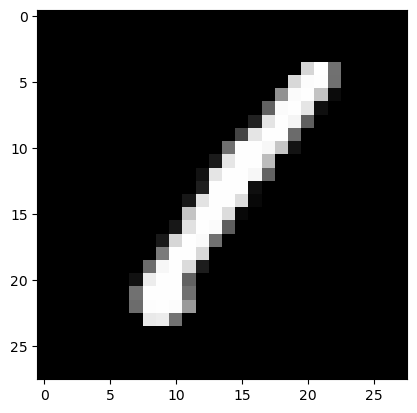

In [13]:
plt.imshow(X[0], cmap=plt.cm.Grays_r)

### Step 4: One-Hot Encode the Labels

In [14]:
y = to_categorical(y, num_classes=10)

In [15]:
print("Shape of y after one-hot encoding:", y.shape)

Shape of y after one-hot encoding: (42000, 10)


### Step 5: Split the Data

In [16]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
print("X_train shape:", X_train.shape)

X_train shape: (33600, 28, 28, 1)


### Step 6: Build the Neural Network Model

In [38]:
class NeuralNetwork(Model):
    def __init__(self):
        super().__init__(name='NeuralNetwork')
        self.flatten = Flatten()
        self.dense1 = Dense(128, activation='relu')
        self.dense2 = Dense(64, activation='relu')
        self.dense3 = Dense(10, activation='softmax')
        self.dropout = Dropout(0.25)

    def call(self, x, training=False):
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.dropout(x, training=training)

        x = self.dense2(x)
        x = self.dropout(x, training=training)

        x = self.dense3(x)
        return x

In [39]:
model = NeuralNetwork()

In [40]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
_ = model(tf.random.normal([1, 28, 28, 1]))

In [42]:
model.summary()

Model: "NeuralNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (1, 784)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (1, 128)                    │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (1, 64)                     │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (1, 10)                     │             650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Step 7: Train the Model

In [43]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8648 - loss: 0.4469 - val_accuracy: 0.9412 - val_loss: 0.1936
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9332 - loss: 0.2188 - val_accuracy: 0.9529 - val_loss: 0.1495
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9488 - loss: 0.1677 - val_accuracy: 0.9636 - val_loss: 0.1188
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9576 - loss: 0.1399 - val_accuracy: 0.9660 - val_loss: 0.1072
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9620 - loss: 0.1219 - val_accuracy: 0.9695 - val_loss: 0.1015
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9663 - loss: 0.1085 - val_accuracy: 0.9712 - val_loss: 0.0971
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9688 - loss: 0.0998 - val_accuracy: 0.9705 - val_loss: 0.0961
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9717 - loss: 0.0889 - 

### Step 8: Evaluate the Model

In [45]:
val_loss, val_accuracy = model.evaluate(X_val, y_val)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - accuracy: 0.9733 - loss: 0.0857


In [46]:
print(f"Validation Accuracy: {val_accuracy * 100:.3f}%")

Validation Accuracy: 97.333%


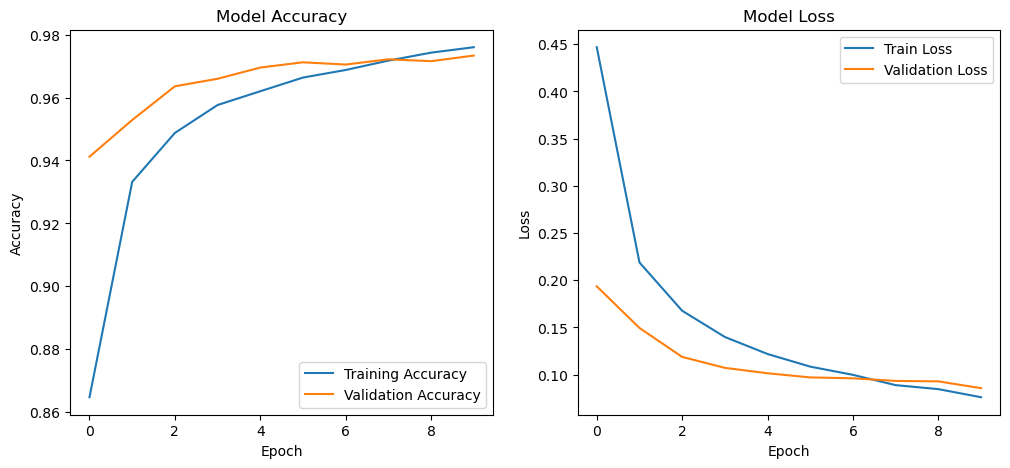

In [47]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

### Step 9: Make Predictions

In [49]:
test_data = pd.read_csv('./data/test.csv')

In [51]:
X_test = test_data.values / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

In [65]:
def plot_predictions(index):
    img = X_test[index]
    pred_label = np.argmax(model.predict(np.expand_dims(img, axis=0)))
    
    plt.imshow(img, cmap=plt.cm.Grays_r)
    plt.title(f"Pred: {pred_label}")
    plt.axis('off')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


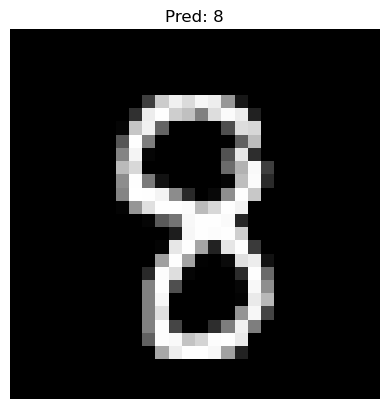

In [71]:
plot_predictions(37)